In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import math

In [2]:
img_path = "../images/lenna.png"
img = cv.imread(img_path, 0)

cv.imshow("Original Image", img)
cv.waitKey(0)
cv.destroyAllWindows()

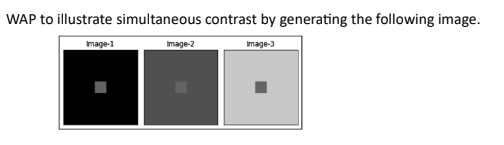

In [3]:
img1 = np.ones((200, 200), dtype=np.uint8) * 0
img2 = np.ones((200, 200), dtype=np.uint8) * 100
img3 = np.ones((200, 200), dtype=np.uint8) * 200

cv.rectangle(img1, (80, 80), (120, 120), 128, -1)
cv.rectangle(img2, (80, 80), (120, 120), 128, -1)
cv.rectangle(img3, (80, 80), (120, 120), 128, -1)

combined = cv.hconcat([img1, img2, img3])

cv.imshow("Simultaneous Contrast", combined)

cv.waitKey(0)
cv.destroyAllWindows()

WAP to transform an image using the following functions. Plot the mapping.
a. Logarithmic function
b. Power law
c. Gamma correction (gamma = 0.5, 2.5)

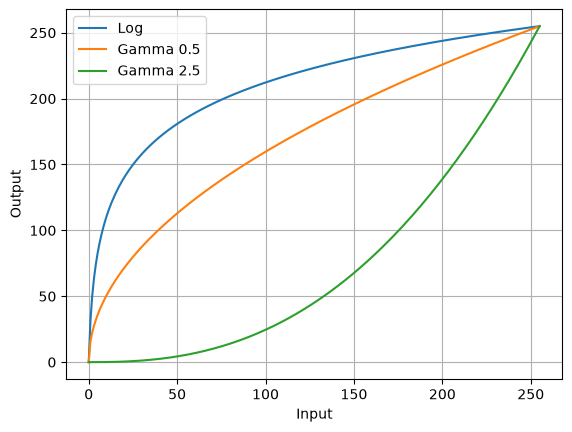

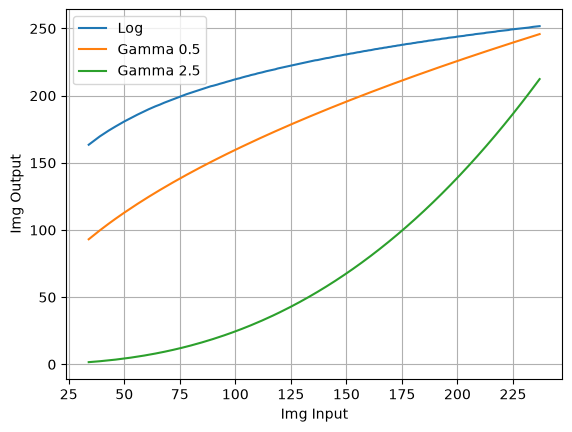

In [4]:
# Log
log_img = 255 * np.log(1 + img) / np.log(256)

# Gamma
gamma05 = 255 * (img / 255) ** 0.5
gamma25 = 255 * (img / 255) ** 2.5

# Show images
cv.imshow("Original", img)
cv.imshow("Log", log_img.astype(np.uint8))
cv.imshow("Gamma 0.5", gamma05.astype(np.uint8))
cv.imshow("Gamma 2.5", gamma25.astype(np.uint8))

cv.waitKey(0)
cv.destroyAllWindows()  

# Plot mapping
x = np.arange(256)

plt.plot(x, 255 * np.log(1 + x) / np.log(256), label="Log")
plt.plot(x, 255 * (x / 255) ** 0.5, label="Gamma 0.5")
plt.plot(x, 255 * (x / 255) ** 2.5, label="Gamma 2.5")

plt.xlabel("Input")
plt.ylabel("Output")
plt.legend()
plt.grid()
plt.show()

x = np.sort(img.flatten())

plt.plot(x, 255 * np.log(1 + x) / np.log(256), label="Log")
plt.plot(x, 255 * (x / 255) ** 0.5, label="Gamma 0.5")
plt.plot(x, 255 * (x / 255) ** 2.5, label="Gamma 2.5")

plt.xlabel("Img Input")
plt.ylabel("Img Output")
plt.legend()
plt.grid()
plt.show()

WAP to implement gray level slicing for the range [100, 150]
a. with background applied to other pixels in the image. Plot the mapping values with the original
intensity in x axis and the modified intensity value in y-axis.
b. Without background applied to other pixels. Plot the mapping value.

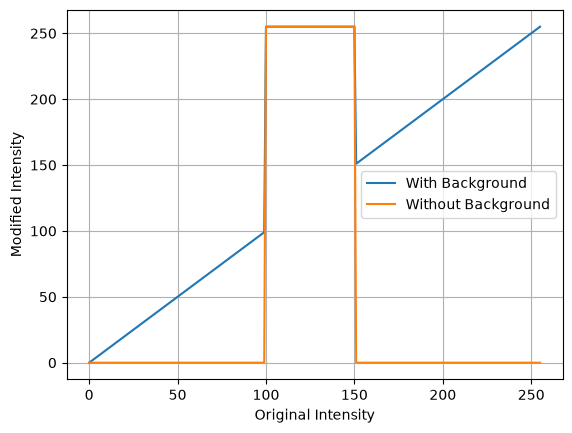

In [5]:
L = 100
H = 150

height, width = img.shape

# A. With background
with_bg = img.copy()

for i in range(height):
    for j in range(width):
        if L <= img[i, j] <= H:
            with_bg[i, j] = 255

# B. Without background
without_bg = np.zeros_like(img)

for i in range(height):
    for j in range(width):
        if L <= img[i, j] <= H:
            without_bg[i, j] = 255

cv.imshow("Original", img)
cv.imshow("With Background", with_bg)
cv.imshow("Without Background", without_bg)

# Mapping
x = np.arange(256)

y_with = x.copy()
y_without = np.zeros(256)

y_with[(x >= L) & (x <= H)] = 255
y_without[(x >= L) & (x <= H)] = 255

plt.plot(x, y_with, label="With Background")
plt.plot(x, y_without, label="Without Background")

plt.xlabel("Original Intensity")
plt.ylabel("Modified Intensity")
plt.legend()
plt.grid()
plt.show()

cv.waitKey(0)
cv.destroyAllWindows()

WAP to implement Piecewise Linear Contrast Enhancement.

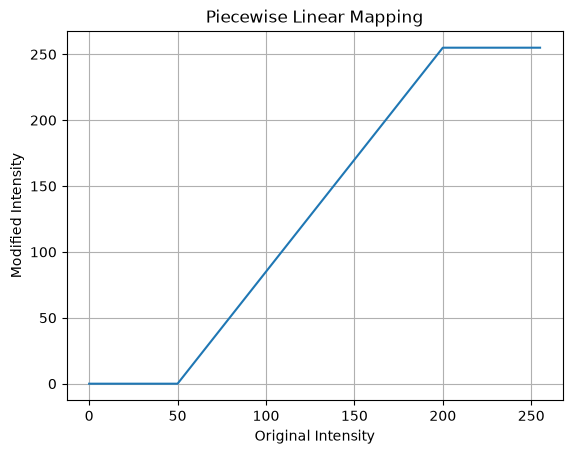

In [6]:
r1 = 50
r2 = 200
s1 = 0
s2 = 255

contrast = img.copy()

height, width = img.shape

for i in range(height):
    for j in range(width):

        if img[i, j] < r1:
            contrast[i, j] = s1

        elif img[i, j] <= r2:
            contrast[i, j] = ((s2 - s1) / (r2 - r1)) * (img[i, j] - r1) + s1

        else:
            contrast[i, j] = s2

contrast = contrast.astype(np.uint8)

cv.imshow("Original", img)
cv.imshow("Contrast Enhanced", contrast)

# Mapping
x = np.arange(256)

y = np.zeros(256)

for i in range(256):
    if i < r1:
        y[i] = s1
    elif i <= r2:
        y[i] = ((s2 - s1) / (r2 - r1)) * (i - r1) + s1
    else:
        y[i] = s2

plt.plot(x, y)
plt.xlabel("Original Intensity")
plt.ylabel("Modified Intensity")
plt.title("Piecewise Linear Mapping")
plt.grid()
plt.show()

cv.waitKey(0)
cv.destroyAllWindows()

Bit plane “n – 1” corresponds to the mostsignificant bit (MSB) and the bit plane “0” to the least significant
bit (LSB). Information content in natural images decreases from MSB to LSB. WAP to segregate the
bitplanes and display all the bit-planes individually.

In [ ]:
bit_planes = []

for bit in range(8):

    bit_plane = np.zeros((height, width), dtype=np.uint8)

    for i in range(height):
        for j in range(width):
            bit_plane[i, j] = (img[i, j] >> bit) & 1

    # 0/1 -> 0/255
    bit_plane = bit_plane * 255
    cv.putText(bit_plane, f"Bit {bit}", (10, 30), 0, 1, 128, 2)
    bit_planes.append(bit_plane)

combined = cv.hconcat(bit_planes)

cv.imshow("Bit Planes", combined)

cv.waitKey(0)
cv.destroyAllWindows()

7. WAP to display the histogram of the given images and analyze.

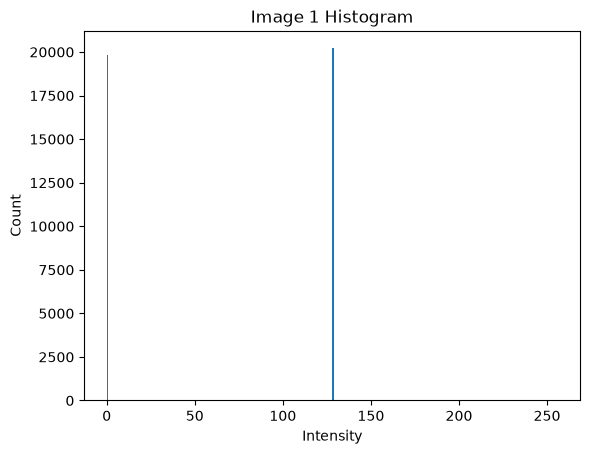

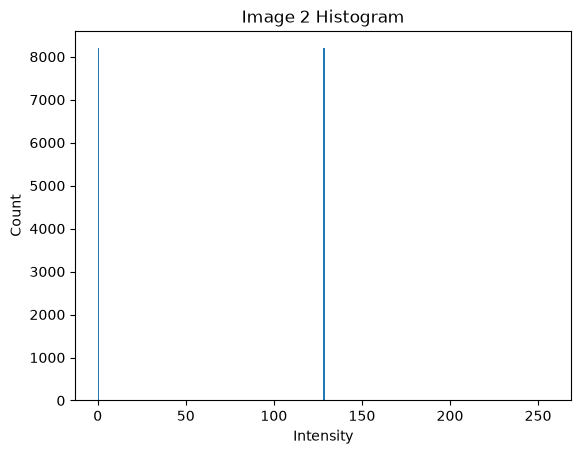

In [13]:
img1 = np.ones((200, 200), dtype=np.uint8) * 128
img2 = np.ones((128, 128), dtype=np.uint8) * 128

height, width = img1.shape[:2]

for i in range(height):
    for j in range(width):
        if (j > 100):
            img1[i, j] = 0

block = 16

for i in range(0, height, block):
    for j in range(0, width, block):
        if (i // block + j // block) % 2 == 0:
            img2[i:i+block, j:j+block] = 0

cv.imshow("Image 1", img1)
cv.imshow("Image 2", img2)

cv.waitKey(0)
cv.destroyAllWindows()

plt.hist(img1.ravel(), bins=256, range=[0, 256])
plt.title("Image 1 Histogram")
plt.xlabel("Intensity")
plt.ylabel("Count")
plt.show()

plt.hist(img2.ravel(), bins=256, range=[0, 256])
plt.title("Image 2 Histogram")
plt.xlabel("Intensity")
plt.ylabel("Count")
plt.show()

8. WAP to demonstrate that histogram equalization is an idempotent operation.

```python
Code for adding gaussian noise to the input image.
mean, variance = 0, 1000
sigma = np.sqrt(variance)
gauss = np.random.normal(mean, sigma, img.shape)
img_noise = img+gauss
```

In [15]:
# Add Gaussian noise
mean, variance = 0, 1000
sigma = np.sqrt(variance)

gauss = np.random.normal(mean, sigma, img.shape)
img_noise = np.clip(img + gauss, 0, 255).astype(np.uint8)


# Equalization - 1st time
hist, _ = np.histogram(img_noise.ravel(), 256, [0, 256])

cdf = hist.cumsum()
cdf_min = cdf[cdf > 0].min()

mapping = ((cdf - cdf_min) / (cdf.max() - cdf_min) * 255).astype(np.uint8)

equalized1 = mapping[img_noise]


# Equalization - 2nd time
hist, _ = np.histogram(equalized1.ravel(), 256, [0, 256])

cdf = hist.cumsum()
cdf_min = cdf[cdf > 0].min()

mapping = ((cdf - cdf_min) / (cdf.max() - cdf_min) * 255).astype(np.uint8)

equalized2 = mapping[equalized1]


cv.imshow("Original", img)
cv.imshow("Noisy", img_noise)
cv.imshow("Equalized Once", equalized1)
cv.imshow("Equalized Twice", equalized2)
cv.imshow("Difference", equalized1 - equalized2)

cv.waitKey(0)
cv.destroyAllWindows()

9. WAP to generate noisy image and apply Mean, Median filters. Do the analysis of
size of the mask and the filters.

In [10]:
# Gaussian noise
mean, variance = 0, 1000
sigma = np.sqrt(variance)

gauss = np.random.normal(mean, sigma, img.shape)
noisy = np.clip(img + gauss, 0, 255).astype(np.uint8)

# Mean filters
mean3 = cv.blur(noisy, (3, 3))
mean5 = cv.blur(noisy, (5, 5))
mean7 = cv.blur(noisy, (7, 7))

# Median filters
median3 = cv.medianBlur(noisy, 3)
median5 = cv.medianBlur(noisy, 5)
median7 = cv.medianBlur(noisy, 7)

cv.imshow("Original", img)
cv.imshow("Noisy", noisy)

cv.imshow("Mean 3x3", mean3)
cv.imshow("Mean 5x5", mean5)
cv.imshow("Mean 7x7", mean7)

cv.imshow("Median 3x3", median3)
cv.imshow("Median 5x5", median5)
cv.imshow("Median 7x7", median7)

cv.waitKey(0)
cv.destroyAllWindows()

In [11]:
# Add Gaussian noise
mean, variance = 0, 1000
sigma = np.sqrt(variance)

gauss = np.random.normal(mean, sigma, img.shape)
noisy = np.clip(img + gauss, 0, 255).astype(np.uint8)


def mean_filter(img, size):

    height, width = img.shape
    pad = size // 2

    padded = np.pad(img, pad, mode="edge")
    result = np.zeros_like(img)

    for i in range(height):
        for j in range(width):

            mask = padded[i:i+size, j:j+size]

            result[i, j] = np.mean(mask)

    return result


def median_filter(img, size):

    height, width = img.shape
    pad = size // 2

    padded = np.pad(img, pad, mode="edge")
    result = np.zeros_like(img)

    for i in range(height):
        for j in range(width):

            mask = padded[i:i+size, j:j+size]

            result[i, j] = np.median(mask)

    return result


# Different mask sizes
mean3 = mean_filter(noisy, 3)
mean5 = mean_filter(noisy, 5)
mean7 = mean_filter(noisy, 7)

median3 = median_filter(noisy, 3)
median5 = median_filter(noisy, 5)
median7 = median_filter(noisy, 7)


cv.imshow("Original", img)
cv.imshow("Noisy", noisy)

cv.imshow("Mean 3x3", mean3)
cv.imshow("Mean 5x5", mean5)
cv.imshow("Mean 7x7", mean7)

cv.imshow("Median 3x3", median3)
cv.imshow("Median 5x5", median5)
cv.imshow("Median 7x7", median7)

cv.waitKey(0)
cv.destroyAllWindows()